Joaquin Campos 22155

Diego Linares 221256

# Task 1


$$
O = \left\lfloor \frac{W - K + 2P}{S} \right\rfloor + 1
$$

Entrada: 

$$
256 \times 256 \times 4
$$

---

## Opción A (Estilo AlexNet)

- Kernel: $7 \times 7$
- Stride: $S = 2$
- Padding: $P = 0$
- Filtros de salida: $C_{out} = 64$


$$
O = \left\lfloor \frac{256 - 7 + 2(0)}{2} \right\rfloor + 1
$$


$$
\frac{249}{2} = \left\lfloor 124.5 \right\rfloor + 1
$$


$$
W_{out} = 125 = H_{out}
$$

$$
125 \times 125 \times 64
$$


## Opción B (Estilo VGG)

La arquitectura consiste en:

- Tres capas convolucionales $3 \times 3$
- Stride $S = 1$
- Padding $P = 1$
- Seguidas de MaxPooling $2 \times 2$ con stride 2

---

## Convolución 1

$$
K = 3, \quad P = 1, \quad S = 1
$$


$$
O = \left\lfloor \frac{256 - 3 + 2(1)}{1} \right\rfloor + 1
$$

$$
255 + 1 = 256
$$


$$
256 \times 256 \times 64
$$

---

## Convolución 2


$$
256 \times 256 \times 64
$$


$$
O = \left\lfloor \frac{256 - 3 + 2}{1} \right\rfloor + 1
$$


$$
256 \times 256 \times 64
$$

---

## Convolución 3


$$
O = \left\lfloor \frac{256 - 3 + 2}{1} \right\rfloor + 1
$$


$$
256 \times 256 \times 64
$$

---

## MaxPooling $2 \times 2$

Configuración:

- Kernel: $K = 2$
- Stride: $S = 2$
- Padding: $P = 0$


$$
O = \left\lfloor \frac{256 - 2}{2} \right\rfloor + 1
$$


$$
\frac{254}{2} = 127
$$

$$
127 + 1 = 128
$$

$$
W_{out} = 128 = H_{out}
$$


$$
128 \times 128 \times 64
$$
---

Opción A :  $125 \times 125 \times 64$:

reduce la dimensión espacial inmediatamente debido al stride 2 y la falta de padding.

Opción B :  $128 \times 128 \times 64$:

mantiene la resolución durante las convoluciones gracias al padding, y solo reduce la dimensión con el max pooling.

# Inciso 2

$$
\text{Parámetros} = (K_w \times K_h \times C_{in}) \times C_{out}
$$

# Opción A (Estilo AlexNet)

Configuración:

- Kernel: $7 \times 7$
- Canales de entrada: $C_{in} = 4$
- Filtros de salida: $C_{out} = 64$


$$
\text{Parámetros} = (7 \times 7 \times 4) \times 64
$$

$$
= 12544
$$


$$
12544 \text{ parámetros entrenables}
$$

---

# Opción B (Estilo VGG)

## Convolución 1

$$
C_{in} = 4
$$

$$
C_{out} = 64
$$

$$
(3 \times 3 \times 4) \times 64
$$


$$
3 \times 3 = 9
$$

$$
9 \times 4 = 36
$$


$$
36 \text{ pesos}
$$

$$
36 \times 64 = 2304
$$

---

## Convolución 2

Ahora la entrada tiene **64 canales**.

$$
C_{in} = 64
$$

$$
(3 \times 3 \times 64) \times 64
$$


$$
576 \times 64 = 36864
$$

---

## Convolución 3

$$
C_{in} = 64
$$

$$
(3 \times 3 \times 64) \times 64
$$

$$
36864
$$

---

Suma:

$$
2304 + 36864 + 36864
$$

$$
= 76032
$$

**Opción B requiere**:

$$
76032 \text{ parámetros entrenables}
$$

---

### Comparación de parámetros

| Arquitectura | Parámetros |
|---------------|-------------|
| Opción A (AlexNet) | $12\,544$ |
| Opción B (VGG) | $76\,032$ |

---

### Justificación usando el Campo Receptivo

El **campo receptivo** es la parte de la imagen de entrada que afecta la activación en una capa determinada.

Una convolución $7\times7$ tiene directamente un campo receptivo de:

$$
7 \times 7
$$

Pero, muchas convoluciones pequeñas pueden producir **un campo receptivo equivalente**.

Tres convoluciones $3\times3$ generan un campo receptivo efectivo de:

$$
7 \times 7
$$

porque cada capa aumenta el campo receptivo en **2 píxeles por lado**.

Esto significa que **tres convoluciones $3\times3$ capturan el mismo contexto espacial que una $7\times7$**.

---

### Por qué la industria estandarizó convoluciones pequeñas

1. **Más no-linealidades**

Cada capa incluye una función de activación (ReLU)

2. **Mayor profundidad**

Las redes más profundas pueden capturar patrones jerárquicos.

3. **Mejor eficiencia computacional**

Aunque haya más capas, las convoluciones son pequeñas tienden a ser más eficientes.

4. **Mayor capacidad de representación**

Varias capas pequeñas permiten construir features más abstractos progresivamente.

---

### Conclusión

Aunque la Opción B tiene más parámetros, tres convoluciones $3\times3$ permiten obtener un **campo receptivo equivalente a $7\times7$**, pero con **mayor profundidad y más funciones de activación**, lo que mejora la capacidad de aprendizaje del modelo.

# Task 2

## Inciso 1 

Los métodos tradicionales como **SIFT** y **HOG** fueron creados para extraer características manualmente a partir de gradientes y bordes. Aunque pueden funcionar bien en condiciones controladas, tienen limitaciones importantes en escenarios agrícolas reales. En un cultivo de mango, las hojas pueden aparecer con distintas intensidades de luz, diferentes ángulos de cámara, cambios de tamaño e incluso con partes tapadas por otras hojas, ramas o frutos. Como SIFT y HOG dependen principalmente de descriptores geométricos, les cuesta adaptarse bien a todas estas variaciones.

Por otro lado, los modelos de **Deep Learning**, especialmente las redes neuronales convolucionales, generan automáticamente feature maps en cada capa. Esto permite que el modelo aprenda representaciones jerárquicas de la imagen: las primeras capas identifican patrones simples como bordes y texturas, mientras que las capas más profundas detectan patrones más complejos como **formas de lesiones, cambios anormales de color o estructuras típicas de enfermedades en las hojas**. Gracias a este aprendizaje por niveles y a la gran cantidad de filtros entrenables, las redes profundas se adaptan mejor a cambios de iluminación, rotación, escala u oclusión parcial. Además, usando **Transfer Learning**, se pueden reutilizar modelos ya entrenados con grandes bases de datos, lo que reduce el tiempo de entrenamiento y la cantidad de datos necesarios para el sistema agrícola.

---

## Inciso 2

Si se debe elegir entre **AlexNet** y **VGG-16** para extraer características de hojas de mango, es más conveniente usar VGG-16. Esta arquitectura utiliza varias convoluciones pequeñas de $3 \times 3$, lo que permite hacer una red más profunda con una estructura simple y ordenada. Esto facilita aplicar Transfer Learning, ya que las primeras capas aprenden patrones visuales generales que pueden reutilizarse en tareas como la detección de enfermedades en hojas.

Además, VGG-16 usa varias capas con activación **ReLU**, que introducen **no-linealidades** en el modelo. Estas no linealidades ayudan a que la red aprenda relaciones más complejas entre los píxeles. En aplicaciones agrícolas, donde las condiciones cambian mucho, esta capacidad de adaptación es clave para lograr un sistema más robusto y preciso.

# Task 3 - Implementacion (Transfer Learning)

Utilizaremos el "Mango Leaf Disease Dataset" disponible en Kaggle. El dataset contiene imágenes de hojas de mango clasificadas en múltiples categorías (sanas y con diversas enfermedades).

Deberá escribir un script en Python (preferiblemente un Jupyter Notebook) utilizando PyTorch o
TensorFlow/Keras para resolver este problema mediante Transfer Learning.



In [7]:

# %pip install torch torchvision scikit-learn matplotlib seaborn tqdm kaggle

In [8]:
import os
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import vgg16, VGG16_Weights

from sklearn.metrics import confusion_matrix, accuracy_score
from IPython.display import Markdown, display
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cpu


In [ ]:

# Configuracion del dataset

DATA_DIR_CANDIDATES = [
    Path('./archive'),
    Path('./data/mango_leaf_disease'),
]
DATA_DIR = next((p for p in DATA_DIR_CANDIDATES if p.exists()), DATA_DIR_CANDIDATES[0])

AUTO_DOWNLOAD = False
KAGGLE_DATASET = 'warcoder/mango-leaf-disease-dataset'

def maybe_download_from_kaggle(dest_dir: Path, dataset_slug: str):
    from kaggle.api.kaggle_api_extended import KaggleApi

    dest_dir.parent.mkdir(parents=True, exist_ok=True)
    api = KaggleApi()
    api.authenticate()
    api.dataset_download_files(dataset_slug, path=str(dest_dir.parent), unzip=True)

if AUTO_DOWNLOAD and (not DATA_DIR.exists()):
    maybe_download_from_kaggle(DATA_DIR, KAGGLE_DATASET)

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f'No se encontro DATA_DIR={DATA_DIR}. Usa la carpeta que contiene clases (ejemplo: ./archive).'
    )

# Validacion minima de formato para ImageFolder
class_dirs = [d for d in DATA_DIR.iterdir() if d.is_dir()]
if len(class_dirs) == 0:
    raise RuntimeError(f'La carpeta {DATA_DIR} no tiene subcarpetas de clase.')

print('DATA_DIR =', DATA_DIR.resolve())
print('Subcarpetas de clase detectadas:', len(class_dirs))


DATA_DIR = C:\Users\dlinares\Documents\UVG\Vision\corto1_Vision\archive
Subcarpetas de clase detectadas: 8


In [ ]:

# Pipeline de datos + Augmentation
IMG_SIZE = 224
BATCH_SIZE = 32
VAL_RATIO = 0.15
TEST_RATIO = 0.15

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

eval_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

dataset_train_view = datasets.ImageFolder(DATA_DIR, transform=train_tfms)
dataset_eval_view = datasets.ImageFolder(DATA_DIR, transform=eval_tfms)

num_samples = len(dataset_train_view)
indices = np.arange(num_samples)
rng = np.random.default_rng(SEED)
rng.shuffle(indices)

test_size = int(num_samples * TEST_RATIO)
val_size = int(num_samples * VAL_RATIO)
train_size = num_samples - val_size - test_size

train_idx = indices[:train_size]
val_idx = indices[train_size:train_size + val_size]
test_idx = indices[train_size + val_size:]

train_ds = Subset(dataset_train_view, train_idx.tolist())
val_ds = Subset(dataset_eval_view, val_idx.tolist())
test_ds = Subset(dataset_eval_view, test_idx.tolist())

num_workers = 0 if os.name == 'nt' else 2
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers)

class_names = dataset_train_view.classes
num_classes = len(class_names)

print(f'Total: {num_samples} | Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
print(f'Numero de clases: {num_classes}')
print('Clases:', class_names)


Total: 4000 | Train: 2800 | Val: 600 | Test: 600
Numero de clases: 8
Clases: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']


In [11]:
# =============================
# Adaptacion de arquitectura (VGG16)
# =============================
model = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)

# Congelar extractor de caracteristicas
for p in model.features.parameters():
    p.requires_grad = False

# Reemplazar la ultima capa fully connected para ajustar al numero de clases
in_features = model.classifier[6].in_features
model.classifier[6] = nn.Linear(in_features, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam((p for p in model.parameters() if p.requires_grad), lr=1e-3)

print(model.classifier)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\dlinares/.cache\torch\hub\checkpoints\vgg16-397923af.pth


100%|██████████| 528M/528M [00:29<00:00, 18.6MB/s] 


Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=8, bias=True)
)


In [12]:
# =============================
# Entrenamiento y validacion
# =============================
EPOCHS = 8

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    all_preds, all_targets = [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            logits = model(x)
            loss = criterion(logits, y)

            if is_train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(y.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    return avg_loss, acc

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer=optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(
        f'Epoch {epoch:02d}/{EPOCHS} | '
        f'train_loss={train_loss:.4f} train_acc={train_acc:.4f} | '
        f'val_loss={val_loss:.4f} val_acc={val_acc:.4f}'
    )


Epoch 01/8 | train_loss=1.0204 train_acc=0.6721 | val_loss=0.2209 val_acc=0.9383
Epoch 02/8 | train_loss=0.6945 train_acc=0.8529 | val_loss=0.3176 val_acc=0.9433
Epoch 03/8 | train_loss=0.5312 train_acc=0.8921 | val_loss=0.0287 val_acc=0.9917
Epoch 04/8 | train_loss=0.5411 train_acc=0.8964 | val_loss=0.0598 val_acc=0.9900
Epoch 05/8 | train_loss=0.6663 train_acc=0.8889 | val_loss=0.0796 val_acc=0.9817
Epoch 06/8 | train_loss=0.4691 train_acc=0.9246 | val_loss=0.0831 val_acc=0.9883
Epoch 07/8 | train_loss=0.4774 train_acc=0.9232 | val_loss=0.0200 val_acc=0.9950
Epoch 08/8 | train_loss=0.4639 train_acc=0.9311 | val_loss=0.0496 val_acc=0.9917


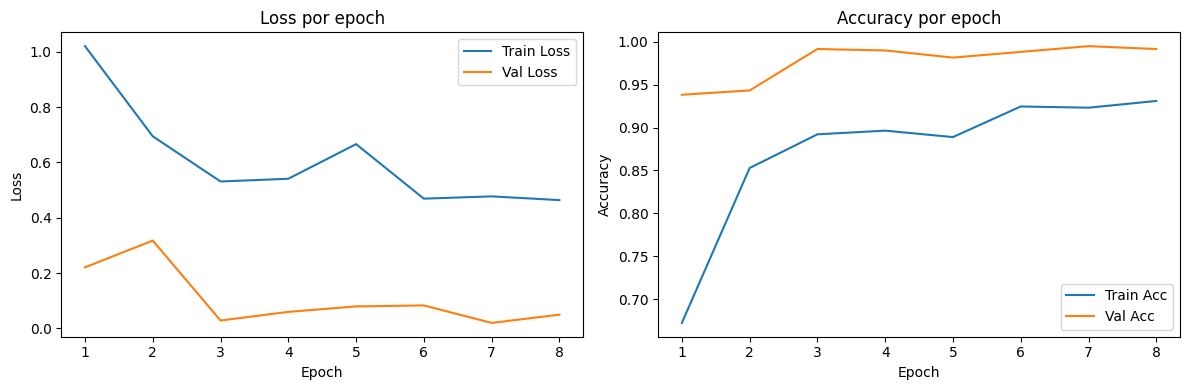

In [13]:
# Curvas de entrenamiento
epochs_axis = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_axis, history['train_loss'], label='Train Loss')
plt.plot(epochs_axis, history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss por epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_axis, history['train_acc'], label='Train Acc')
plt.plot(epochs_axis, history['val_acc'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy por epoch')
plt.legend()

plt.tight_layout()
plt.show()


### Conclusión breve del bloque de curvas
- La loss de entrenamiento baja de forma general (con pequeñas oscilaciones), indicando que el modelo sí está aprendiendo patrones útiles.
- La loss de validación se mantiene muy baja y la accuracy de validación se estabiliza cerca de 0.99, lo que sugiere buena capacidad de generalización.
- La brecha entre train y val no muestra una divergencia peligrosa en esta corrida, por lo que no hay evidencia fuerte de sobreajuste en estas 8 épocas.


Evaluando test: 100%|██████████| 19/19 [00:48<00:00,  2.53s/it]

Accuracy global en test: 0.9867


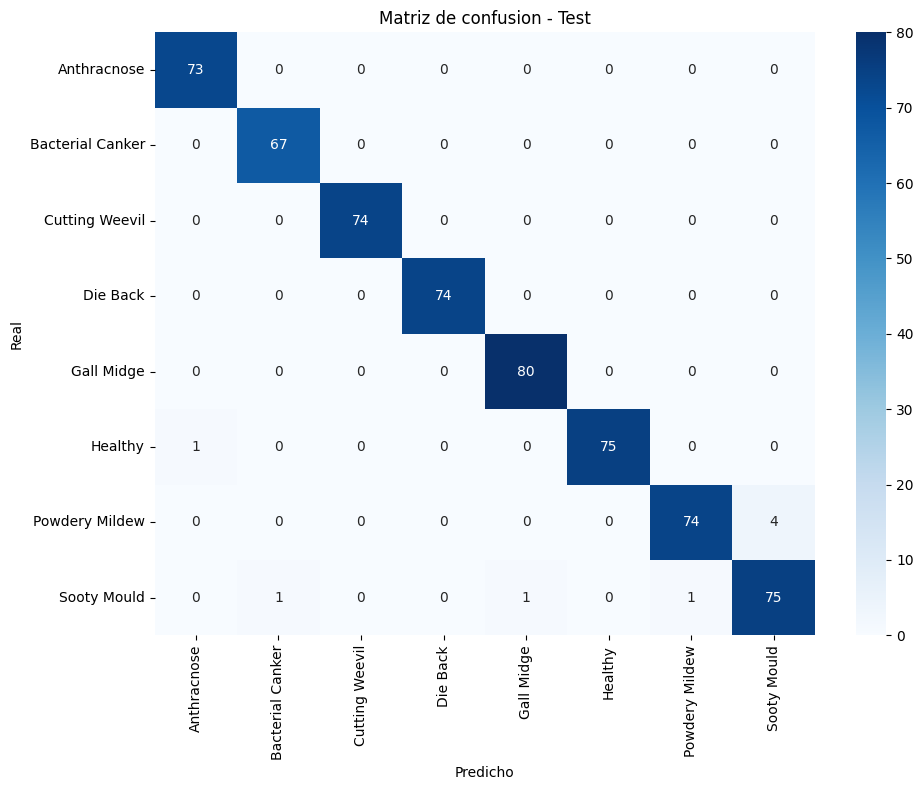

In [14]:
# =============================
# Evaluacion en test + Matriz de confusion
# =============================
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for x, y in tqdm(test_loader, desc='Evaluando test'):
        x = x.to(device)
        logits = model(x)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        y_pred.extend(preds)
        y_true.extend(y.numpy())

test_acc = accuracy_score(y_true, y_pred)
print(f'Accuracy global en test: {test_acc:.4f}')

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de confusion - Test')
plt.tight_layout()
plt.show()



Precision global (Accuracy en test): 0.9867


No se observa sobreajuste fuerte: 

Entrenamiento y validacion se mantienen relativamente cercanos. El Dropout del clasificador de VGG16 contribuye a mejorar la generalizacion. Aun asi, se recomienda monitorear la brecha train-val al aumentar epocas.

## Conclusiones 

### 1) Pipeline de datos
- Se cargaron 4000 imagenes y 8 clases, con split reproducible: 2800 train / 600 val / 600 test.
- El *data augmentation* (rotacion, recorte aleatorio y flip) junto con normalizacion ImageNet permitio entrenar de forma estable desde las primeras epocas.

### 2) Adaptacion de arquitectura
- Se uso VGG16 preentrenado y se congelaron las capas convolucionales para conservar filtros ya aprendidos (texturas/bordes).
- Solo se reemplazo y entreno la capa final para 8 clases, reduciendo costo de entrenamiento y aprovechando Transfer Learning.

### 3) Entrenamiento y backpropagation
- Evolucion observada: train_acc de 0.6721 -> 0.9311 y val_acc entre 0.9383 y 0.9950 en 8 epocas.
- Hubo pequenas oscilaciones en val_loss, pero la tendencia general fue buena y sin inestabilidad fuerte.

### 4) Evaluacion y reporte
- Resultado final en test: Accuracy = 0.9867.
- La matriz de confusion (visualizada arriba) respalda buen desempeno general y pues los errores residuales probablemente aparecen entre clases con sintomas visuales parecidos.
- En esta corrida no se evidencia sobreajuste severo y el uso de Dropout en el clasificador de VGG16 ayuda a la generalizacion.
